In [1]:
using Base.Threads
println( "Number of threads: ", nthreads() )

include( "../args.jl" )
include( "../model.jl" )
include( "../geom.jl" )
include( "../recur.jl" )

Number of threads: 24
Loaded network.jl class file.
Loaded model.jl class file.
Loaded geom.jl class file.
Loaded recur.jl class file.


In [2]:
# Case and data folder, default parameters.
μ = 1.0
N = 100;  ξ = 0.1;  ρ = 0.1;  β = 1.0;  δt = 1e-1
case = "../data/results/case-2_crit-spd/"
pop = "N-$(N)/xi-$(round( ξ, digits=6 ))/rho-$(round( ρ, digits=6 ))_beta-$(round( β, digits=6))/"

# Import default scale.
ϕ = 0.25
dparams = loadparams( case*"default-params.json" )
dscale = loadscale( case*pop*"default-scale.json" )
dnondim = Nondim( dparams; scale=dscale )

# Temporal variables.
T = defInt( 5000 )
tlist = 0:1/2:T

# Import parameter data.
μlist = sort( vcat( readdlm( case*pop*"mu-list.txt" )... ) )
Nμ = length( μlist )

# Number of parameter combinations.
M = 1
println( "Important simulation data for $(Nμ) unique parameter cases." )

# Adapatable time-step length.
smin = -3;  smax = 0
Ns = Nμ;  Δs = (smax - smin)/(Ns-1)
slist = round.( 10.0.^(smin:Δs:smax), digits=6 )
println( "Running for $(Ns) different values of s0." )

Important simulation data for 51 unique parameter cases.
Running for 51 different values of s0.


In [3]:
# Data folder name.
folderdata = [[case*pop*"mu-$(round( μ, digits=6 ))/spd-$(round( s, digits=6 ))/"
    for s ∈ 10.0.^(smin:Δs:smax)./dscale.T^(ϕ + 1)] for μ ∈ μlist];

In [4]:
# Import parameter data.
paramslist = [[loadparams( folder*"params.json" )
    for folder ∈ folderlist] for folderlist ∈ folderdata]

# Import activity and determinism data.
adatadata = [[readdlm( folder*"activity_T-$(round( defInt, T )).txt" )
    for folder ∈ folderlist] for folderlist ∈ folderdata]
ςdatalist = [hcat( [readdlm( folder*"determinism_T-$(round( defInt, T )).txt" ) for folder ∈ folderlist]... )
    for folderlist ∈ folderdata];

In [5]:
# Determinism statistics.
ς̄data = [vcat( mean( ςdata, dims=1 )... ) for ςdata ∈ ςdatalist];

In [6]:
# Import determinism under default parameter case.
ŝlist = round.( 10.0.^(-3:0.25:1), digits=6 )  # NON-DIMENSIONAL.
ς̂data = hcat( [readdlm( case*"N-$(N)/mu-$(round( μ, digits=6 ))/rho-$(round( ρ, digits=6 ))_beta-$(round( β, digits=6 ))"
    *"/xi-$(round( ξ, digits=6 ))/spd-$(round( s/ξ^(ϕ + 1), digits=6 ))/"
    *"determinism_T-$(round( defInt, T )).txt" ) for s ∈ ŝlist]... )

# Compute mean and standard devation.
ς̂list = vcat( mean( ς̂data, dims=1 )... )
ς̂stnd = vcat( std(  ς̂data, dims=1 )... )

# Compute critical parameter estimates.
μc = criticalμ( dnondim, N )

0.5656854249492383

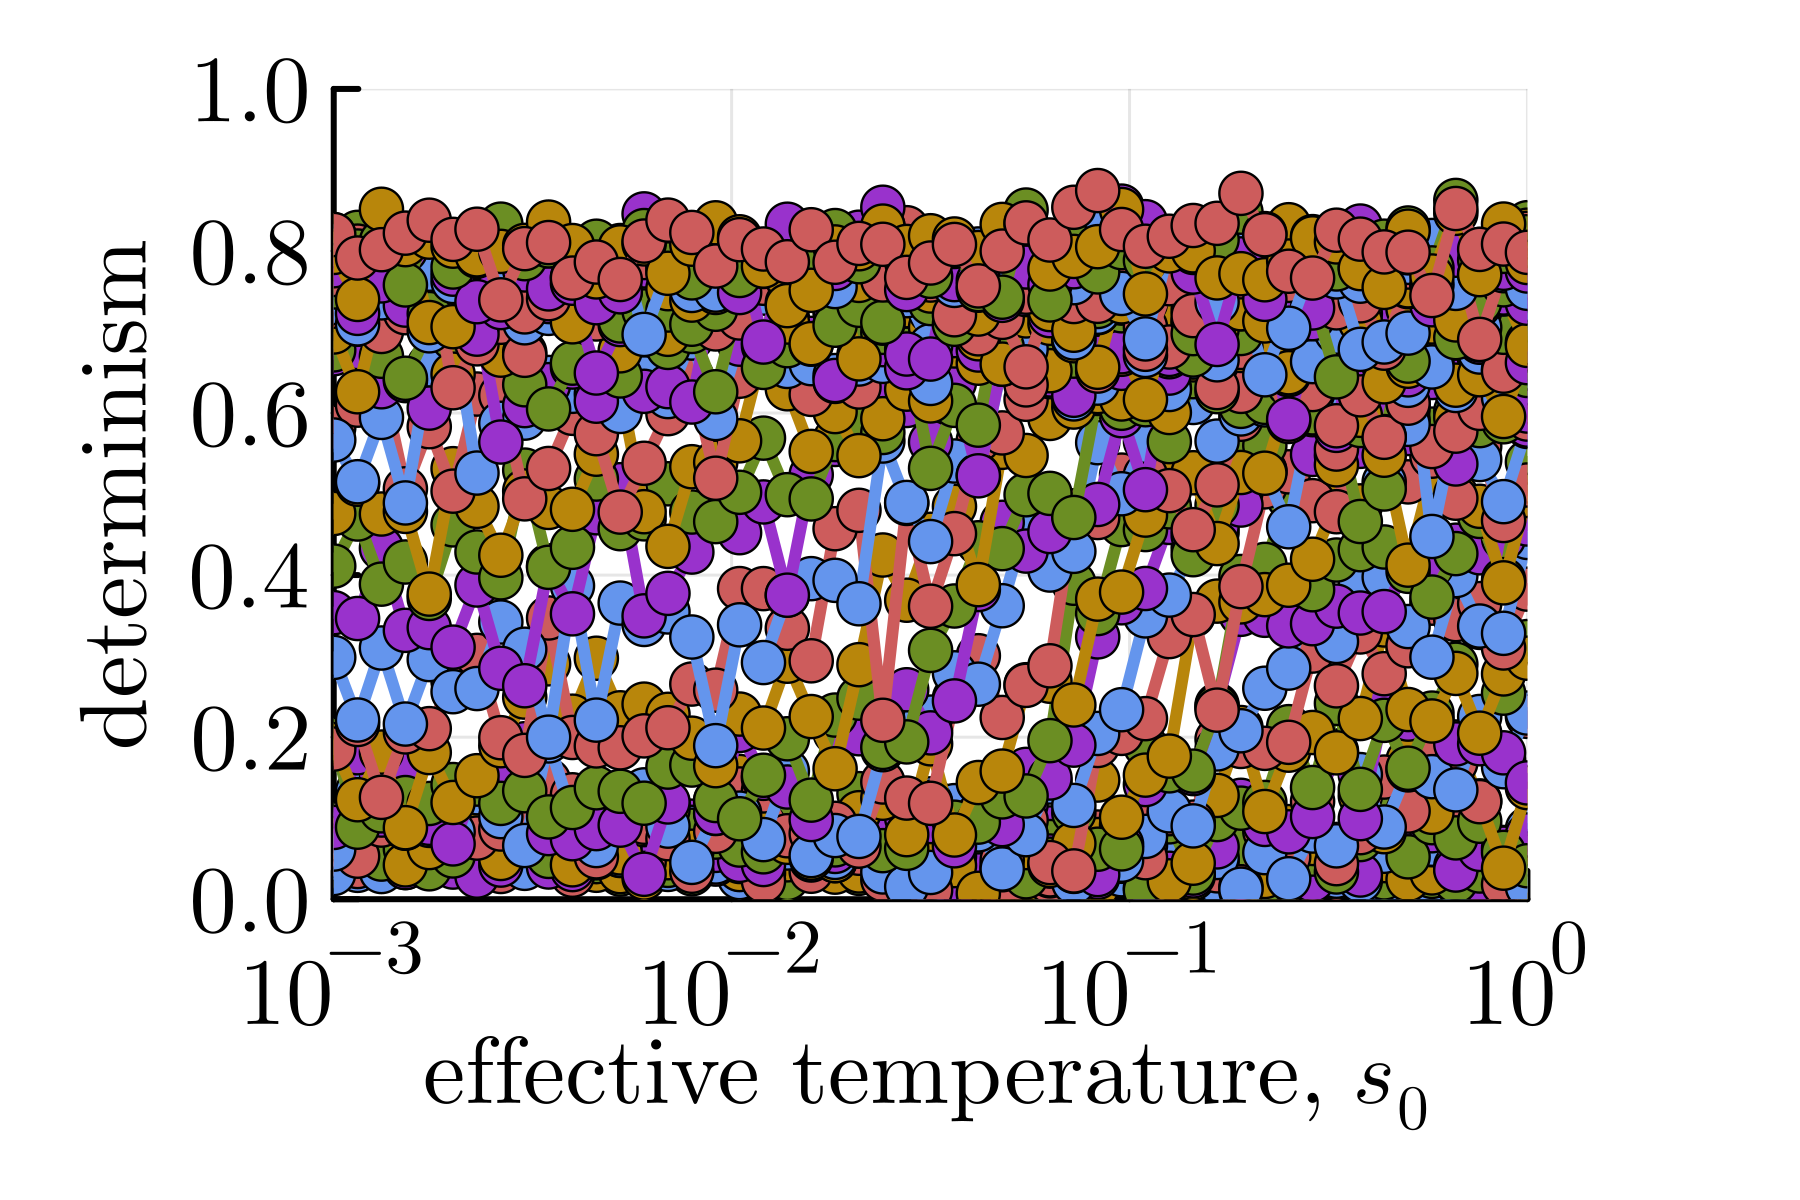

In [7]:
# Plot the determinism in each case for visual inspection.
plt = plot( size=(300,200), xformatter=:plain, dpi=600 )

for (k, ς̄list) ∈ enumerate( ς̄data )
    plot!( plt, slist, ς̄list; lw=2, marker=:circ, label="" )
end

plot!( plt; xlims=(slist[1],slist[end]), xscale=:log10 )
plot!( plt; ylims=(0,1) )

plot!( plt; xlabel="effective temperature, "*L"s_0", ylabel="determinism", legend=:outerright )

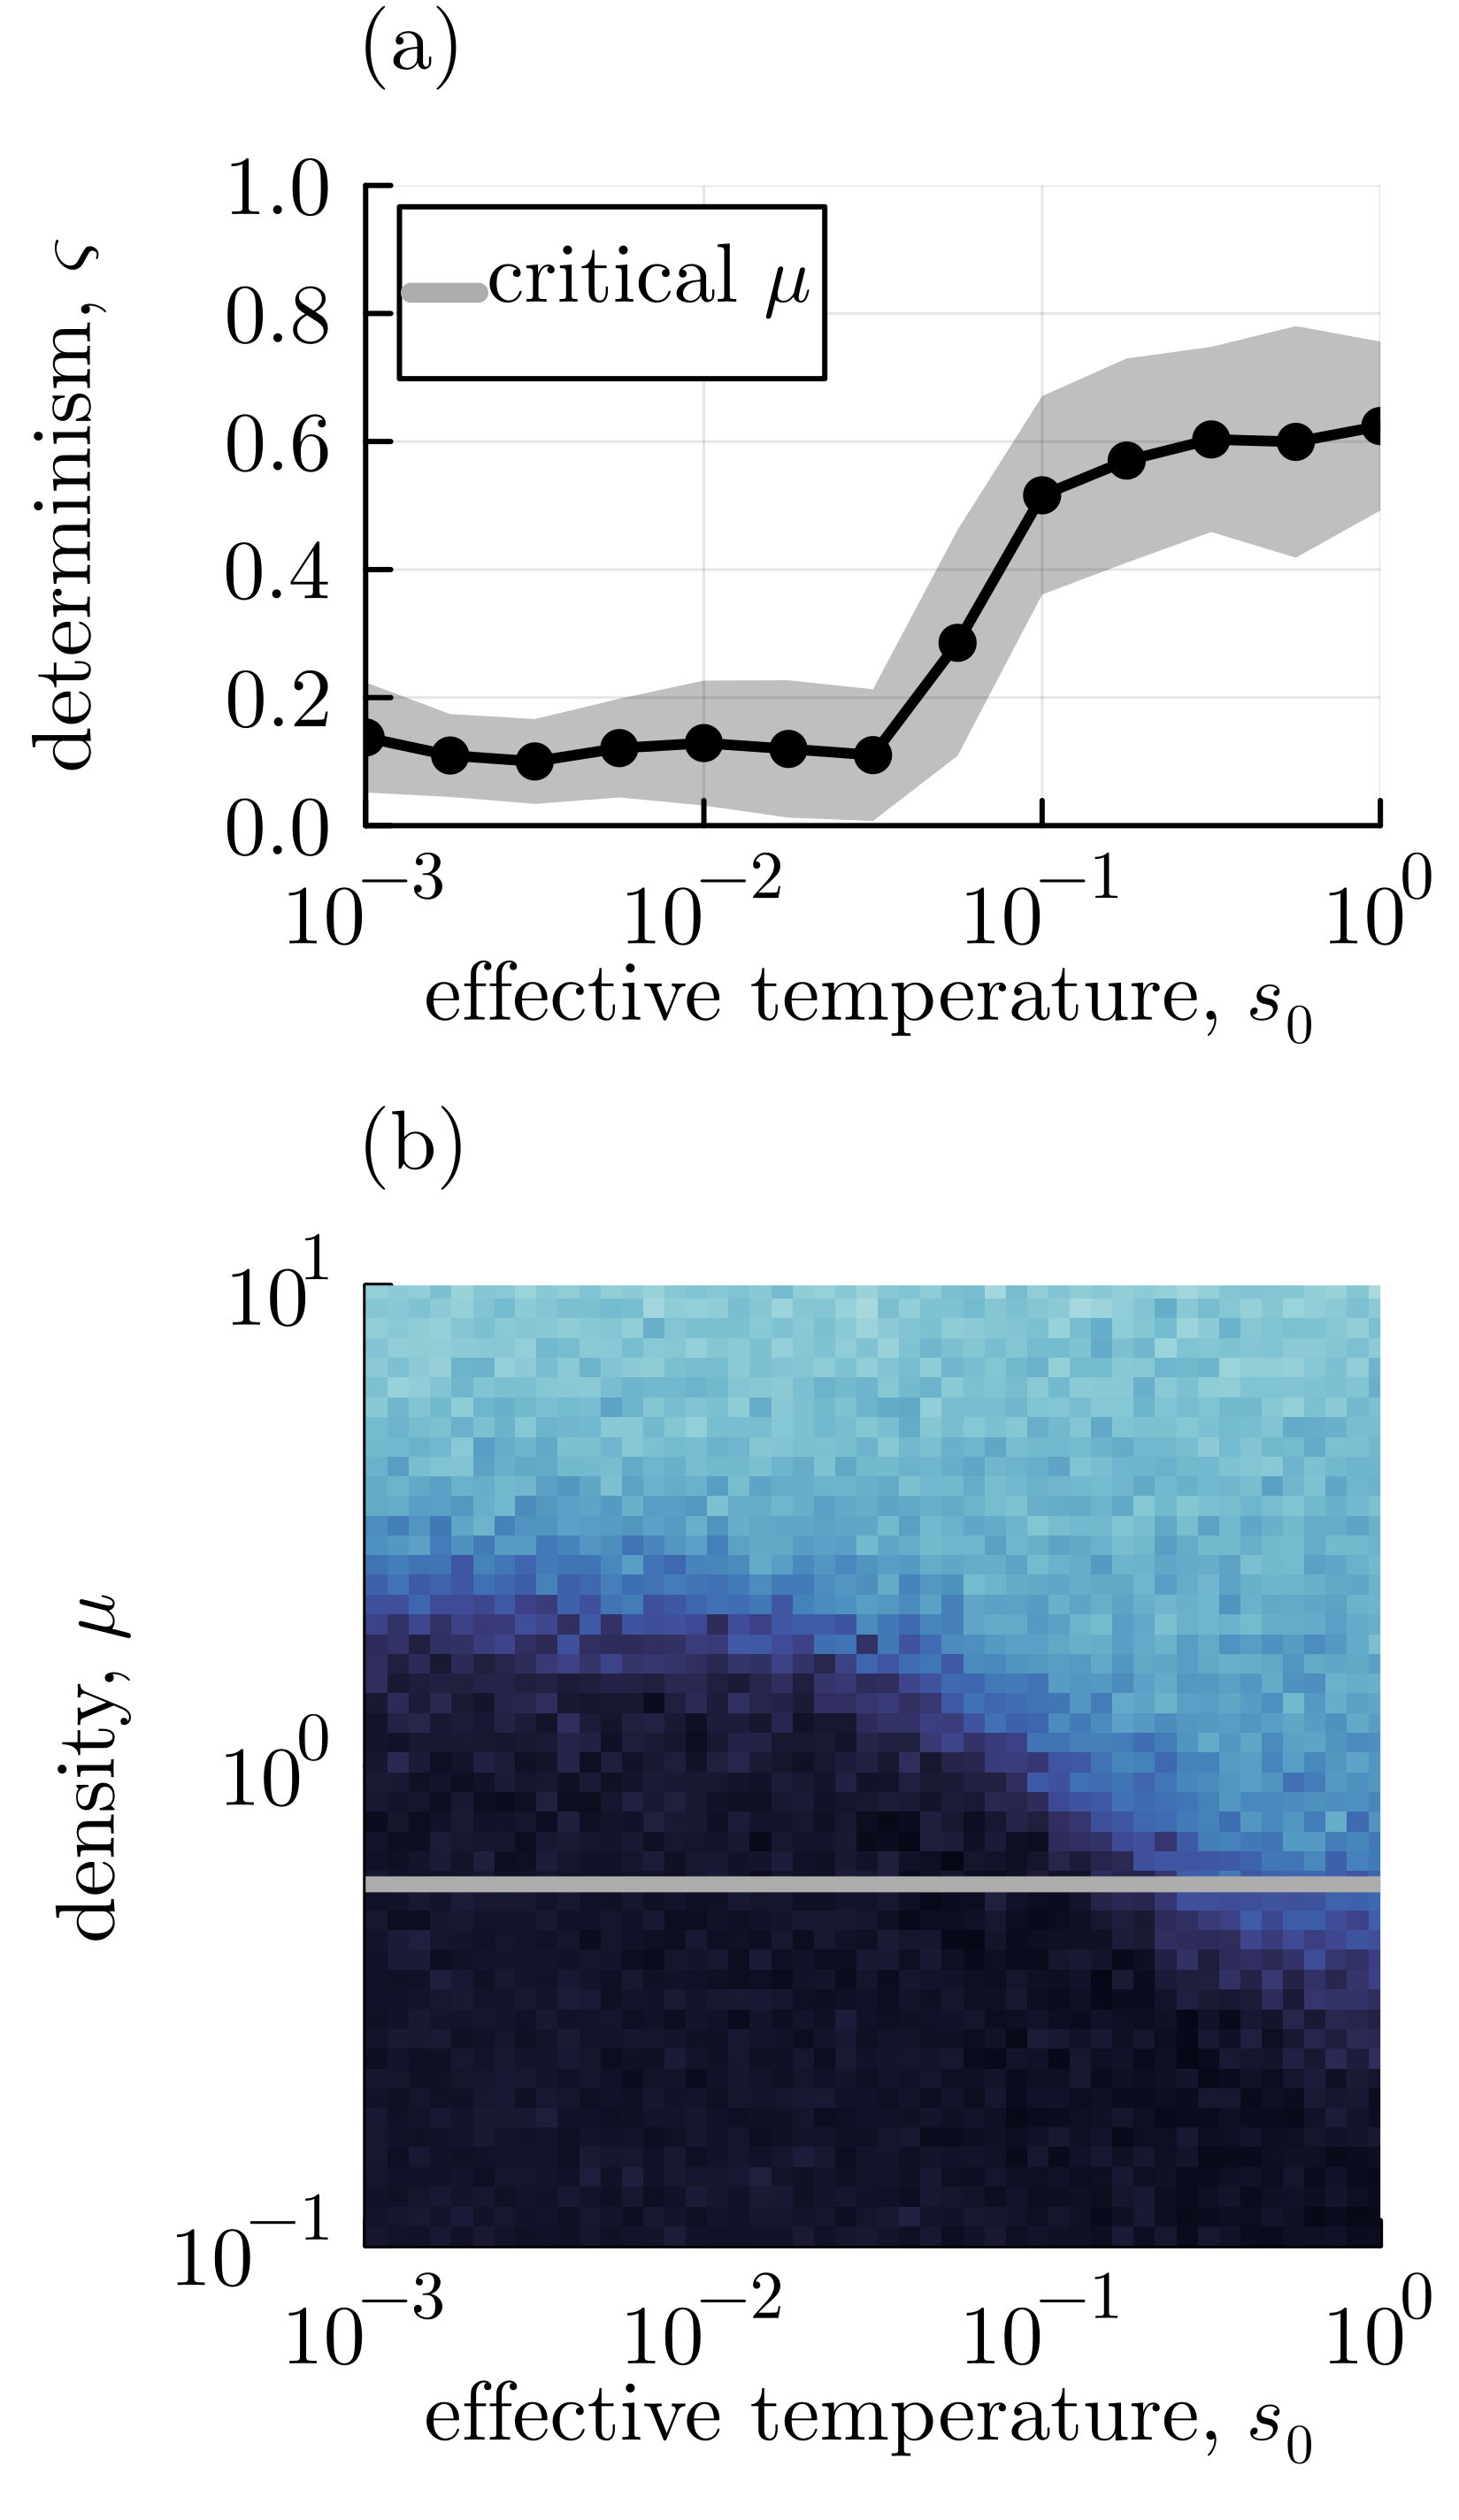

In [8]:
cmap = cgrad( :ice, [1, 2]./3, rev=false )

# Generate heat map of determinism as a function of ρ and β.
plt = plot( layout=@layout([a; b{0.6h}]), size=(275,475), dpi=600 )
plot!( plt; left_margin=5pt, bottom_margin=-5pt )

# # Plot the temperature-dependent phase transition.
plot!( plt[1], [10.0^(-4.0)], [10.0^(-2.0)]; color=:gray68, lw=3, label="critical "*L"μ" )
plot!( plt[1], ŝlist, ς̂list; ribbon=ς̂stnd, color=:black, fillalpha=1/4, lw=2, marker=:circ, label="" )

plot!( plt[1]; xlims=(slist[1],slist[end]), xscale=:log10 )
plot!( plt[1]; ylims=(0,1) )

title!( plt[1], "(a)"; title_position=:left )

plot!( plt[1]; xlabel="effective temperature, "*L"s_0", ylabel="determinism, "*L"ς"*"\n", legend=:topleft )

# Plot the density-dependent phase transition.
heatmap!( plt[2], slist, μlist, hcat( ς̄data... )'; cmap=cmap, clims=(0,1), colorbar=false )
plot!( plt[2], [slist[1],slist[end]], [μc, μc]; color=:gray68, lw=3 )

plot!( plt[2]; xlims=(slist[1],slist[end]), xscale=:log10 )
plot!( plt[2]; ylims=(μlist[1],μlist[end]), yscale=:log10 )

title!( plt[2], "(b)"; title_position=:left )

plot!( plt[2]; xlabel="effective temperature, "*L"s_0", ylabel="density, "*L"μ", legend=false )

saveplot( plt, figurefolder*"determinism-vs-spd_mu.png"; background=:white )

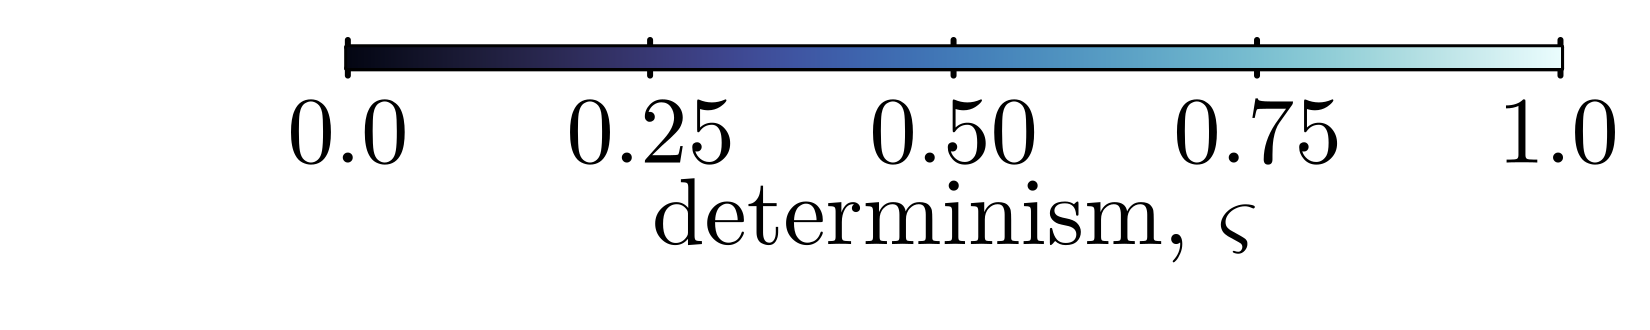

In [9]:
# Create dummy gradient data.
N = 1000
vals = reshape(range(0, 1, length=N), 1, :)

# Plot the gradient to make colorbar.
plt = plot( size=(275,55), xformatter=:plain, dpi=600 )

plot!( plt; left_margin=36pt, right_margin=5pt, top_margin=0pt, bottom_margin=15pt )

heatmap!( plt, vals; c=cmap, clims=(0,1),
    colorbar=false, ytick=false, yticks=false,
    framestyle=:box,
    xticks=( [1, round(Int,N/4), round(Int,N/2), round(Int,3N/4), N],
              ["0.0","0.25","0.50","0.75","1.0"] ) )

plot!( plt; xlabel="determinism, "*L"ς" )

saveplot( plt, figurefolder*"determinism-vs-spd_mu_colorbar.png"; background=:white )